# motor analysis code
Sawyer Fuller, 2025.12.17

2026.03.06: incorporated motor data from Semayat

2026.04.03 more semayat data, rotor aero simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

def get_row_index(df, rowname, col=0):
    'get an index from a row name. For assigning single elements to a dataframe'
    if isinstance(col, int):
        return np.flatnonzero(df.iloc[:,col]==rowname)[0]
    elif isinstance(col, str):
        return np.flatnonzero(df[col]==rowname)[0]

def get_row(df, rowname):
    'get a single row from a dataframe (rather than a view of multiple rows) '
    idx = get_row_index(df, rowname)
    return df.loc[idx], idx

rpm2rads = 2 * np.pi / 60
gcm2Nm = 1/1000*9.8/100
gcm2Nm

9.800000000000001e-05

urls:

1. https://www.microprivod.ru/catalogue/pdf/faulhaber/servo/EN_0206B_DFF.pdf or in 25_papers/2025 flybar/faulhaber_0206.pdf (discontinued)
1. https://www.faulhaber.com/en/products/series/0308b/#lower

2. https://www.faulhaber.com/en/products/series/0515b/

3. https://www.faulhaber.com/en/products/series/0615s/
3. https://eshop.faulhaber.com/en/0620K006B/0620K006B - note motor curve plot seems wrong - power is too low and suggests 72pct max efficiency, their datasheet says 52% which is what this curve gets

4. https://microdcmotors.com/product/3-2mm-coreless-dc-motor-8mm-length-type-model-nfp-3a-03208b
5. https://microdcmotors.com/product/4mm-micro-coreless-motor-7-6mm-type-model-nfp-d04076
5. https://microdcmotors.com/product/4mm-3v-coreless-motor-8mm-length-type-model-nfp-d0408
5. https://microdcmotors.com/product/4mm-coreless-dc-motor-8mm-type-model-nfp-d0408fs
5. https://microdcmotors.com/product/4mm-3-7v-types-of-micro-motors-12mm-model-nfp-d0412-3978

6. https://micromotorpro.com/product/4mm-coreless-electric-motor-tsl-cl0412/ 0408-750 (hottest one)
5. https://micromotorpro.com/product/4mm-coreless-dc-motor-12mm-tsl-d0412/ model: 065091 (hottest one)

6. https://micromotorpro.com/product/6mm-dc-micro-coreless-motor-tsl-d0610/

7. https://micromotorpro.com/product/6mm-coreless-motor-12mm-tsl-cl0612/

8. https://orbray.com/en/product/dccorelessmotor/brushless_ca_bmn04-08.html

9. hand-collected data from mdm3

10. same, from https://microflierradio.com/micro-direct-drive-motors.html (unknown MFR)

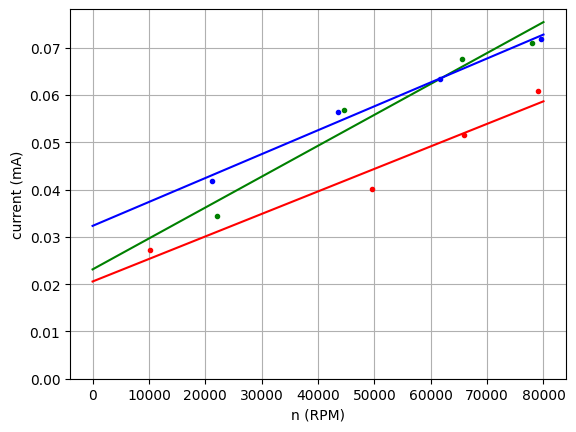

In [2]:
motors = pd.DataFrame(
# motor name, diameter, length, mass, nominal voltage, resistance, n=RPMs, io=no_load-current, K is Nm/A, max efficiency, $price, max current, max power, max (stall) torque, coulomb (static) friction torque, dynamic (omega-dependent) torque
columns=['motor','dia','l','m','v','R','no','io','K','etamax','cost','imax','Pmax','Ts', 'Tc', 'b'],
data=[
    ['fh2bl',     1.9,5.5,90.,1,7.2,100000,0.032,0.000076,0.27,None,None,0.13,0.0000095, 1e-6,  1.5e-11/rpm2rads],
    ['fh3bl',     3.,8.,350.,3,34,61000,0.027,0.00032,0.2,200,None,0.034,0.000026,       1.8e-6,1.09e-10/rpm2rads],
    ['fh5bl',     5.,14.6,1600.,6.,16.1,43000,0.056,0.00115,0.39,200,None,0.330,0.0004,  33e-6, 6.5e-10/rpm2rads],
    ['fh6',       6,15.0,2000.,3.,16.2,20300,0.0156,0.0013,0.51,None,None,0.088,0.000221, None, None],
    ['fh6bl',     6,20,  2500, 6, 8.8, 48600,0.056, 0.0011,0.51,None,None,0.927,0.000475,11e-6,10.2e-10/rpm2rads],
    ['mdm3',      3,8.0,None,None,30.0,30000.0,None,None,None,5.0,0.12,None,None,None],
    ['mdm4a',     4,7.6,500.0,3.5,None,31500.0,0.045,0.000627,None,3.0,0.07,None,None],
    ['mdm4b',     4,8.0,500.0,3.7,9.0,88000.0,0.059,0.00033,0.36,3.0,0.41,0.261,None],
    ['mdm4c',     4,12.1,700.0,3.7,5.3,78000.0,0.053,0.0004,0.49,3.0,0.7,0.52,0.00026],
    ['mdm4d',     4,12.1,700.0,3.0,2.8,86000.0,0.025,0.00029,0.49,0.0,1.07,0.63,0.00029],
    ['tsl48a',    4,12.0,500.0,3.4,11.0,75000.,0.070,None,None,None,0.309,0.2,0.0001],
    ['tsl412a',   4,12.0,800.0,3.0,8.7,59100.0,0.045,0.0004,None,None,0.35,None,0.00012],
    ['tsl6a',     6,10.0,1200,3.0,4.5, 52200.0,0.075,0.0045, 0.41, None, 0.67, 0.37, .000272],
    ['tsl6b',     6,12.0,None,3.7,4.8, 48100.0,0.045,0.0048, 0.55, None, 0.77, None, .000483],
    ['orbray4',   4,8.5,700,3,30.5,37600,0.0031,0.00052,0.19,None,0.98,.035,.04],
    ['subgram3',  3,8,283,4,13.5,79000,0.061, None,None,5.,None,None,None], # mdm3 measured
    ['gram4',     4,12,665,4,4.6,78000,0.071,None,None,10,None,None,None], # measured from microflierradio
    ['multigram6',6,12,1230,4,1.23,79500,0.072, None, None, None, None, None, None]])

# calculations needed for a few values
def Kv_rpm2K(Kv):
    "compute K from Kv given in RPMs/V"
    return 1/(Kv / 60 * 2 * np.pi) # Nm/A, motor constant K
_motor, _idx = get_row(motors, 'subgram3')
motors.loc[_idx,'K'] = (_motor.v - _motor.io*_motor.R)/(_motor.no * rpm2rads)
_motor, _idx = get_row(motors, 'gram4')
motors.loc[_idx,'K'] = (_motor.v - _motor.io*_motor.R)/(_motor.no * rpm2rads)
_motor, _idx = get_row(motors, 'multigram6')
motors.loc[_idx,'K'] = (_motor.v - _motor.io*_motor.R)/(_motor.no * rpm2rads)
_motor, _idx = get_row(motors, 'tsl48a')
motors.loc[_idx,'K'] = Kv_rpm2K(1/(.04 / 1000)) #(_motor.v - _motor.io*_motor.R)/(_motor.no * rpm2rads)
#print(motors.loc[_idx,'K'], Kv_rpm2K(1/(.04 / 1000)))
_motor, _idx = get_row(motors, 'tsl412a')
motors.loc[_idx,'K'] = Kv_rpm2K(1/(.04 / 1000)) #(_motor.v - _motor.io*_motor.R)/(_motor.no * rpm2rads)
#print(Kv_rpm2K(22600), (_motor.v - _motor.io*_motor.R)/(_motor.no * rpm2rads)) checking, they give about same answer

# ------
# use data to linear fit static and viscous drag
# uses coincopter motors at 2, 3, 4v from semayat https://docs.google.com/spreadsheets/d/1A2_l8gRRtJzyzayDyE377LKXn18E5xMKtDOolJdjVRI/edit?gid=0#gid=0
do_plot = 1
n_range = np.array((0, 80e3))
# subgram   49.5krpm 40.1mA, 65.9krpm 51.5v, 79.0k 60.9mA.
_motor, _idx = get_row(motors, 'subgram3')
_data = pd.DataFrame(columns=['v', 'n', 'i'],
                           data=[[1, 10.1*1000, 27.2/1000,  ],
                                  [2, 49.5*1000, 40.1/1000,  ],
                                 [3, 65.9*1000, 51.5/1000, ],
                                 [4, 79.0*1000, 60.9/1000]])
_data['Td'] = _data.i * _motor.K  # drag torque due to combo of static drag (Tc) and vel-dependent drag (b)
_data_coeffs = np.polyfit(_data.n * rpm2rads, _data.Td, 1) # b in Nms/rad, Tc in Nm, in descending power of omega.
motors.loc[_idx,'b'], motors.loc[_idx,'Tc'] = _data_coeffs
if do_plot: plt.plot(_data.n, _data.i, 'r.', n_range, (_data_coeffs[1] + _data_coeffs[0] * n_range*rpm2rads)/_motor.K,'r-')

# gram      44.6k 56.9,      65.5k 67.6,     78.0k 71.0mA.
_motor, _idx = get_row(motors, 'gram4')
_data = pd.DataFrame(columns=['v', 'n', 'i'],
                           data=[[1, 22.0*1000, 34.4/1000],
                                 [2, 44.6*1000, 56.9/1000],
                                 [3, 65.5*1000, 67.6/1000],
                                 [4, 78.0*1000, 71.0/1000]])
_data['Td'] = _data.i * _motor.K  # drag torque due to combo of static drag (Tc) and vel-dependent drag (b)
_data_coeffs = np.polyfit(_data.n * rpm2rads, _data.Td, 1) # b in Nms/rad, Tc in Nm, in descending power of omega.
motors.loc[_idx,'b'], motors.loc[_idx,'Tc'] = _data_coeffs
if do_plot: plt.plot(_data.n, _data.i, 'g.', n_range, (_data_coeffs[1] + _data_coeffs[0] * n_range*rpm2rads)/_motor.K,'g-')

# multigram 43.5k 56.4mA,    56.5k 69.8mA,   79.5k 71.8mA.
_motor, _idx = get_row(motors, 'multigram6')
_data = pd.DataFrame(columns=['v', 'n', 'i'],
                           data=[[1, 21.2*1000, 41.8/1000, ],
                                 [2, 43.5*1000, 56.4/1000, ],
                                 [3, 61.7*1000, 63.5/1000, ],#56.5*1000, 69.8/1000 ],
                                 [4, 79.5*1000, 71.8/1000]])
_data['Td'] = _data.i * _motor.K  # drag torque due to combo of static drag (Tc) and vel-dependent drag (b)
_data_coeffs = np.polyfit(_data.n * rpm2rads, _data.Td, 1) # b in Nms/rad, Tc in Nm, in descending power of omega.
motors.loc[_idx,'b'], motors.loc[_idx,'Tc'] = _data_coeffs
if do_plot: plt.plot(_data.n, _data.i, 'b.', n_range, (_data_coeffs[1] + _data_coeffs[0] * n_range*rpm2rads)/_motor.K,'b-')

motors['bx1e10'] = motors.b*1e10

if do_plot: plt.xlabel('n (RPM)'); plt.ylabel('current (mA)'); plt.grid(); plt.ylim(0, None); plt.show()

In [3]:
motors.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
motor,fh2bl,fh3bl,fh5bl,fh6,fh6bl,mdm3,mdm4a,mdm4b,mdm4c,mdm4d,tsl48a,tsl412a,tsl6a,tsl6b,orbray4,subgram3,gram4,multigram6
dia,1.9,3.0,5.0,6.0,6.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,6.0,6.0,4.0,3.0,4.0,6.0
l,5.5,8.0,14.6,15.0,20.0,8.0,7.6,8.0,12.1,12.1,12.0,12.0,10.0,12.0,8.5,8.0,12.0,12.0
m,90.0,350.0,1600.0,2000.0,2500.0,NaN,500.0,500.0,700.0,700.0,500.0,800.0,1200.0,NaN,700.0,283.0,665.0,1230.0
v,1.0,3.0,6.0,3.0,6.0,NaN,3.5,3.7,3.7,3.0,3.4,3.0,3.0,3.7,3.0,4.0,4.0,4.0
R,7.2,34.0,16.1,16.2,8.8,30.0,NaN,9.0,5.3,2.8,11.0,8.7,4.5,4.8,30.5,13.5,4.6,1.23
no,100000.0,61000.0,43000.0,20300.0,48600.0,30000.0,31500.0,88000.0,78000.0,86000.0,75000.0,59100.0,52200.0,48100.0,37600.0,79000.0,78000.0,79500.0
io,0.032,0.027,0.056,0.0156,0.056,NaN,0.045,0.059,0.053,0.025,0.07,0.045,0.075,0.045,0.0031,0.061,0.071,0.072
K,0.000076,0.00032,0.00115,0.0013,0.0011,NaN,0.000627,0.00033,0.0004,0.00029,0.000382,0.000382,0.0045,0.0048,0.00052,0.000384,0.00045,0.00047
etamax,0.27,0.2,0.39,0.51,0.51,NaN,NaN,0.36,0.49,0.49,NaN,NaN,0.41,0.55,0.19,NaN,NaN,NaN


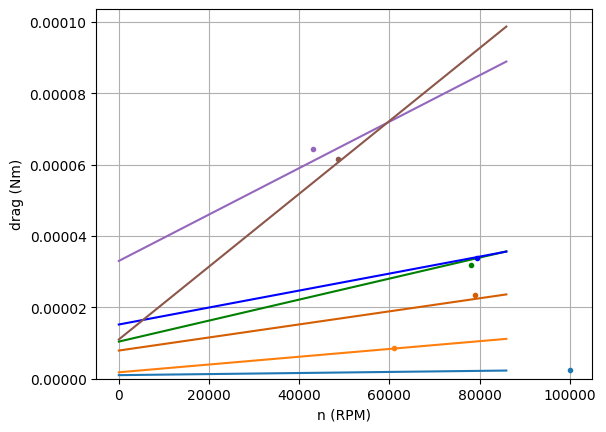

In [4]:
# rpm vs drag. coincopter motors are r, g, b standard used in paper
omegarange = np.linspace(0, 90e2, 20)

# plot coincopter data
_motor = get_row(motors, 'subgram3')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = '#D55E00'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.', color=_c )
_motor = get_row(motors, 'gram4')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = 'g'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.', color=_c )
_motor = get_row(motors, 'multigram6')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = 'b'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.', color=_c )

# plot faulaber data
# faulhaber 2mm
_motor = get_row(motors, 'fh2bl')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = 'C0'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.', color=_c )
# faulhaber 3mm
_motor = get_row(motors, 'fh3bl')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = 'C1'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.',color=_c )
# faulhaber 5mm
_motor = get_row(motors, 'fh5bl')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = 'C4'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.',color=_c )
# faulhaber 6mm
_motor = get_row(motors, 'fh6bl')[0]
_motor_coeffs = (_motor.b, _motor.Tc)
_c = 'C5'
plt.plot(omegarange/rpm2rads, np.polyval(_motor_coeffs, omegarange), '-', [_motor.no,], [_motor.io*_motor.K,], '.',color=_c )

plt.grid()
plt.ylim((0, None))
plt.xlabel('n (RPM)')
plt.ylabel('drag (Nm)');

In [5]:
def motor_curves_vs_T_compare(motor, v=None, show_comparison=True, figsize=(6,4), dpi=300, title="Rename"):
    if v is None:
        v = motor.v

    Ts_2 = motor.K*(v/motor.R - motor.io)
    T_2 = np.linspace(0, Ts_2, 500)
    T_uNm_2 = T_2 * 1e6
    i_2 = T_2/motor.K + motor.io
    Omega_2 = -motor.R/motor.K**2 * T_2 - motor.R/motor.K*motor.io + v/motor.K
    N_2 = Omega_2 / rpm2rads
    P_2 = T_2 * Omega_2
    eta_2 = P_2 / (i_2 * v)

    Ts = motor.K*v/motor.R - motor.Tc
    T = np.linspace(0, Ts, 500)
    T_uNm = T * 1e6
    Omega = motor.K/(motor.R*motor.b + motor.K**2)*(v - motor.R/motor.K*(T + motor.Tc))
    i = 1 / motor.K * (T + motor.Tc + motor.b*Omega)
    N = Omega / rpm2rads
    P = T * Omega
    eta = P / (i * v)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.subplots_adjust(left=0.14, right=0.70, top=0.88)

    twin1 = ax.twinx()
    twin2 = ax.twinx()
    twin3 = ax.twinx()

    # move the actual axes outward
    twin1.spines["right"].set_position(("outward", 0))
    twin2.spines["right"].set_position(("outward", 55))
    twin3.spines["right"].set_position(("outward", 110))

    # cleaner overlapping behavior
    twin1.patch.set_visible(False)
    twin2.patch.set_visible(False)
    twin3.patch.set_visible(False)

    twin1.yaxis.tick_right()
    twin2.yaxis.tick_right()
    twin3.yaxis.tick_right()

    twin1.yaxis.set_label_position("right")
    twin2.yaxis.set_label_position("right")
    twin3.yaxis.set_label_position("right")

    alpha = 0.5 if show_comparison else 0

#     # Define a manual color scheme  |  ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF']
# color_scheme = {
#     "Flat propeller": "#ABABAB", # light gray
#     "Long flexures": "#5F9ED1",  # #88CCEE light cyan
#     "Short flexures": "#FF800E", # orange
#     "Curved Short": "#117733",   # green
#     "Curved Long": "purple",
#     "MicronWings": "black"
# }

    p0, = ax.plot(T_uNm_2, N_2, "k", alpha=alpha, linewidth=2, label=r"$N$")
    p0, = ax.plot(T_uNm, N, "k", linewidth=2, label=r"$N$")

    p1, = twin1.plot(T_uNm_2, P_2, "#D55E00", alpha=alpha, linewidth=2, label="$P$")
    p1, = twin1.plot(T_uNm, P, "#D55E00", linewidth=2, label="$P$")

    p2, = twin2.plot(T_uNm_2, eta_2, "#117733", alpha=alpha, linewidth=2, label=r"$\eta$")
    p2, = twin2.plot(T_uNm, eta, "#117733", linewidth=2, label=r"$\eta$")

    p3, = twin3.plot(T_uNm_2, i_2, "C0", alpha=alpha, linewidth=2, label=r"$i$")
    p3, = twin3.plot(T_uNm, i, "C0", linewidth=2, label=r"$i$")

    ax.set(xlim=(0, None), ylim=(0, None), xlabel=r"$T$ ($\mu$ Nm)", ylabel=r"$N$ (RPM)")
    # ax.set_xlim(0, 100)
    # ax.set_xticks(np.arange(0, 101, 20))
    twin1.set(ylim=(0, None), ylabel="$P$ (W)")
    # twin1.set_yticks(np.arange(0, P.max(), 0.05))
    twin2.set(ylim=(0, 1), ylabel=r"$\eta$")
    twin3.set(ylim=(0, None), ylabel=r"$i$")

    # color labels
    ax.yaxis.label.set_color(p0.get_color())
    twin1.yaxis.label.set_color(p1.get_color())
    twin2.yaxis.label.set_color(p2.get_color())
    twin3.yaxis.label.set_color(p3.get_color())

    # color spines
    ax.spines["left"].set_color(p0.get_color())
    twin1.spines["right"].set_color(p1.get_color())
    twin2.spines["right"].set_color(p2.get_color())
    twin3.spines["right"].set_color(p3.get_color())

    # color ticks
    ax.tick_params(axis='y', colors=p0.get_color(), labelsize=12, width=1.25)
    twin1.tick_params(axis='y', colors=p1.get_color(), labelsize=12, width=1.25)
    twin2.tick_params(axis='y', colors=p2.get_color(), labelsize=12, width=1.25)
    twin3.tick_params(axis='y', colors=p3.get_color(), labelsize=12, width=1.25)
    ax.tick_params(axis='x', labelsize=12, width=1.25)

    # modest label padding
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1000)} k'))
    ax.set_ylabel(r"RPM (thousands)", fontsize=14)
    twin1.set_ylabel("$P$ (W)", fontsize=14, labelpad=1)
    twin2.set_ylabel(r"$\eta$", fontsize=14, labelpad=1)
    twin3.set_ylabel(r"$i$", fontsize=14, labelpad=1)
    ax.set_xlabel(r"$T$ ($\mu$ Nm)", fontsize=14, labelpad=1)

    ax.set_title(title, fontsize=14, pad=14)

    return fig, ax

(<Figure size 1800x1200 with 4 Axes>,
 <Axes: title={'center': 'Sub-gram Motor'}, xlabel='$T$ ($\\mu$ Nm)', ylabel='RPM (thousands)'>)

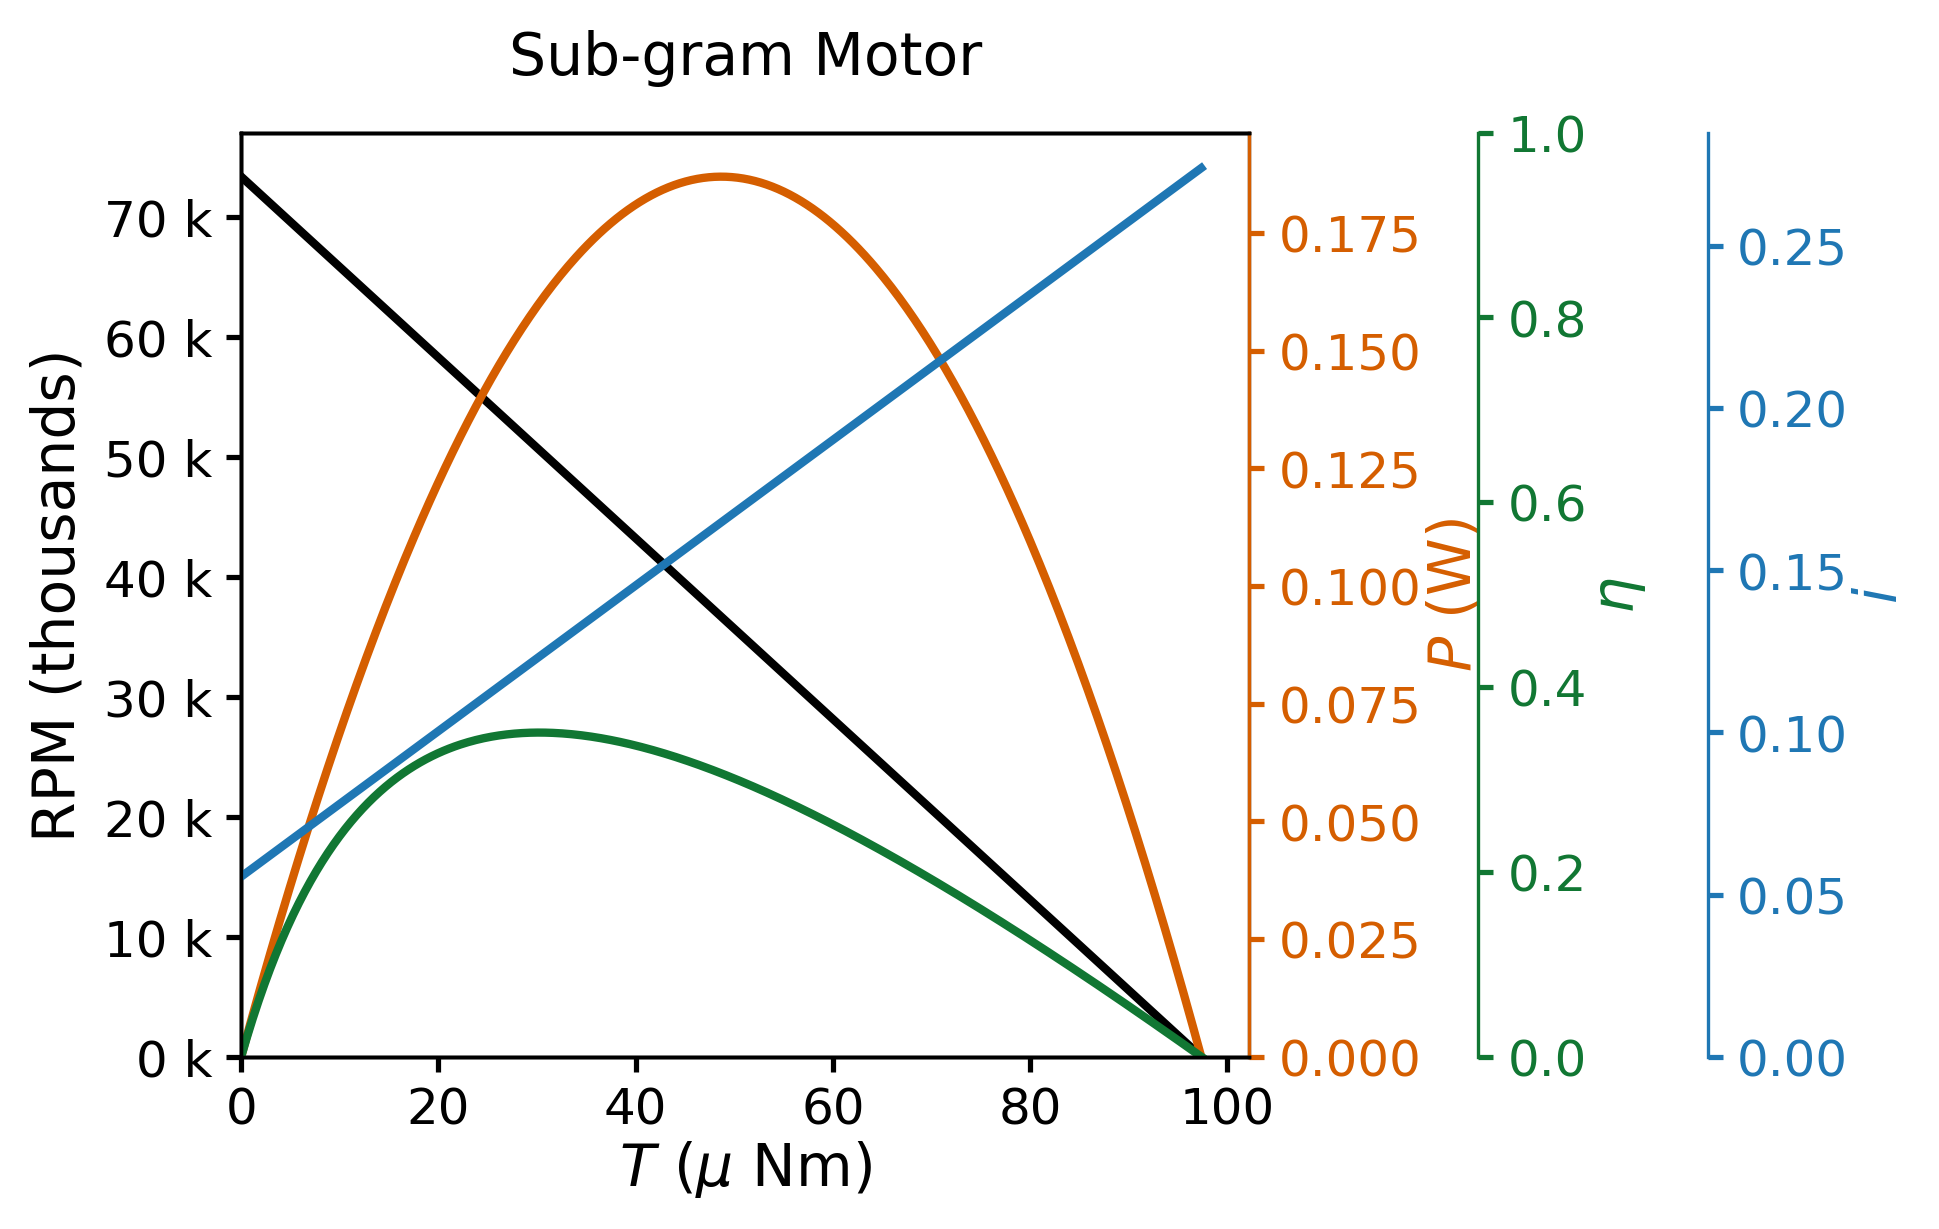

In [6]:
motor_curves_vs_T_compare(get_row(motors, 'subgram3')[0], v=3.7, show_comparison=False, title="Sub-gram Motor")#, v=1.75)
# plt.axvline(52, linestyle=':')

(<Figure size 1800x1200 with 4 Axes>,
 <Axes: title={'center': 'Gram-scale Motor'}, xlabel='$T$ ($\\mu$ Nm)', ylabel='RPM (thousands)'>)

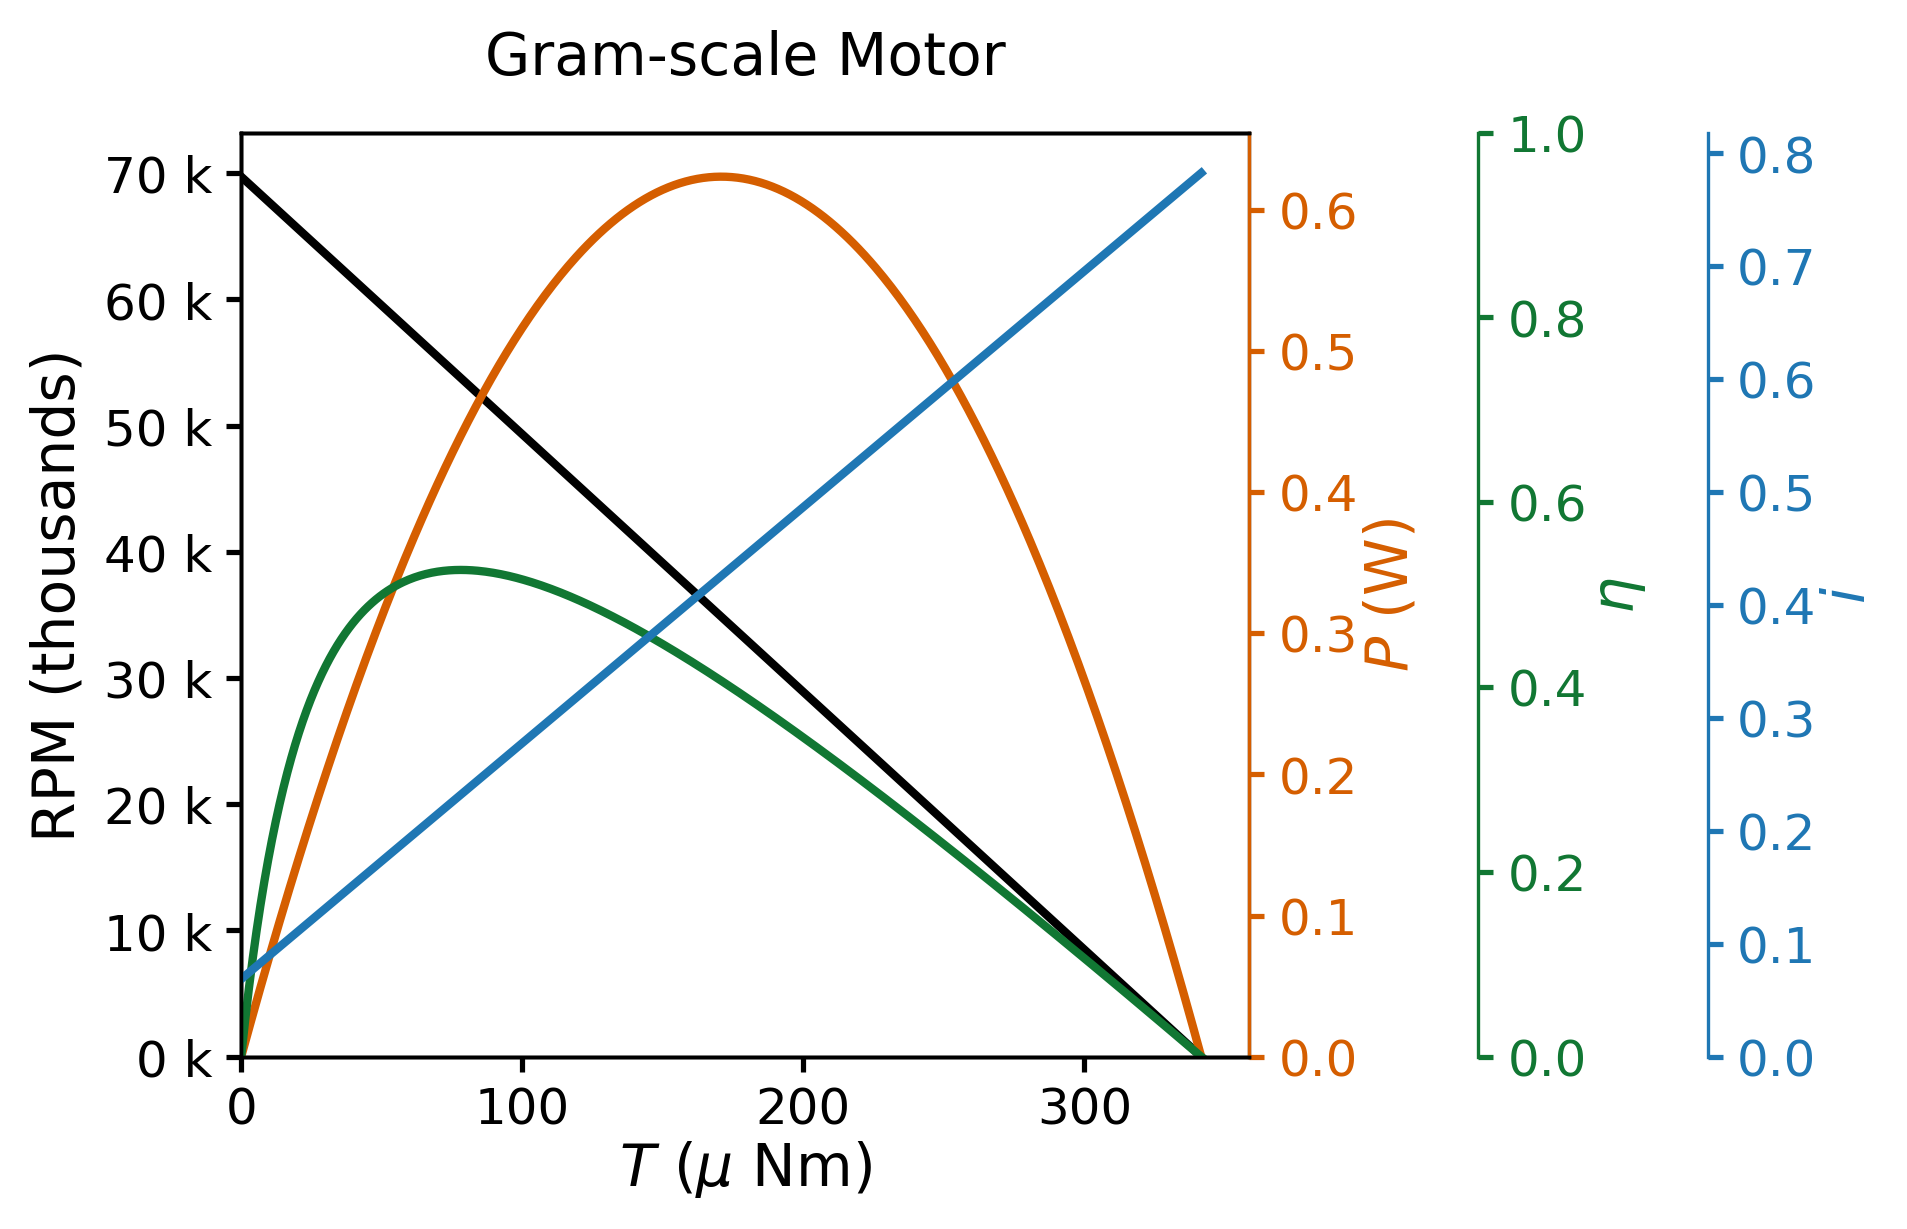

In [7]:
motor_curves_vs_T_compare(get_row(motors, 'gram4')[0], v=3.6, show_comparison=False, title="Gram-scale Motor")#, v=1.75)
# plt.axvline(52, linestyle=':')

(<Figure size 1800x1200 with 4 Axes>,
 <Axes: title={'center': 'Multi-gram Motor'}, xlabel='$T$ ($\\mu$ Nm)', ylabel='RPM (thousands)'>)

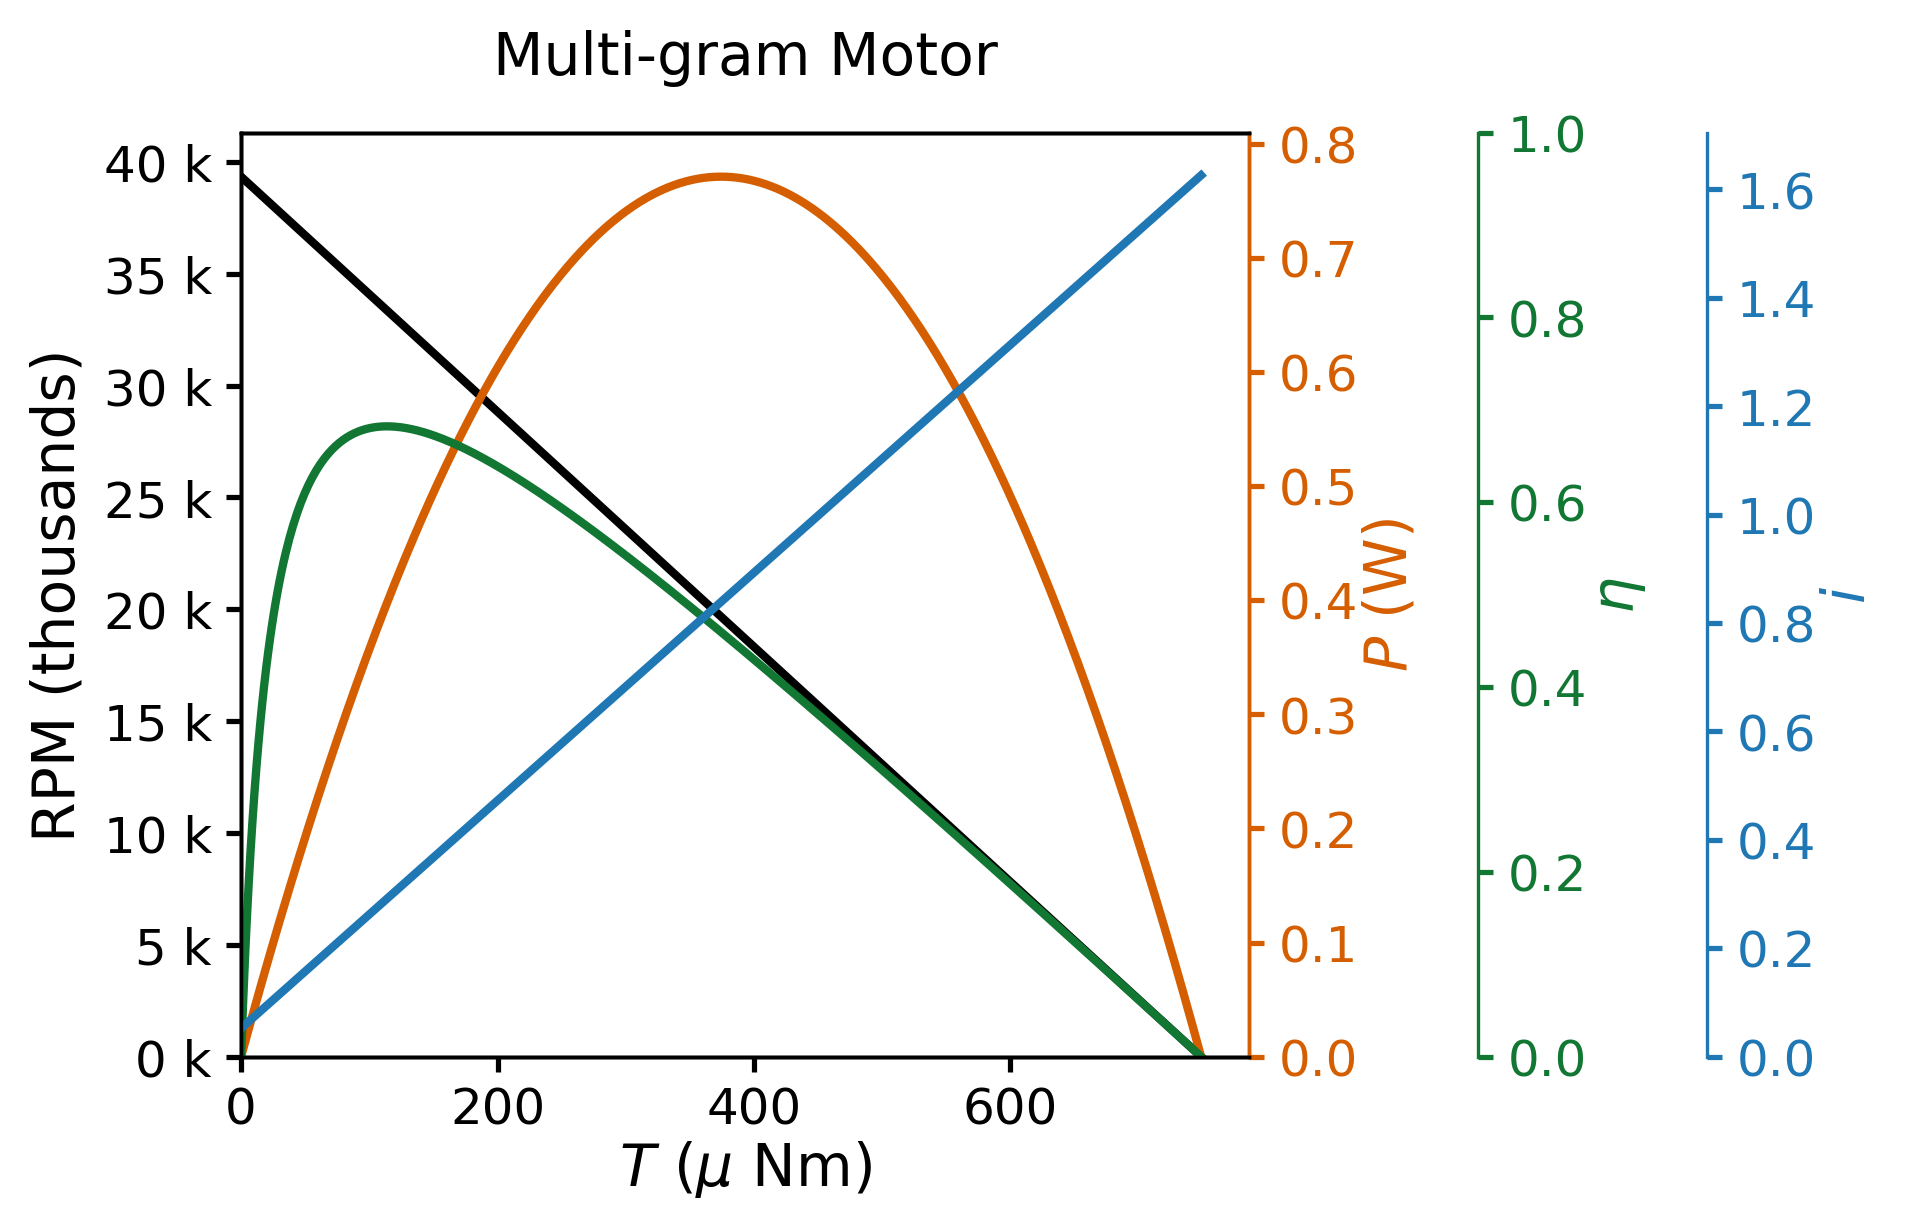

In [8]:
motor_curves_vs_T_compare(get_row(motors, 'multigram6')[0], v=2, show_comparison=False, title="Multi-gram Motor")#, v=.92)
# plt.axvline(350, ls=':')

In [9]:
def motor_curves_vs_T(motor, v2=None):
    "plot motor curves with T as the independent axis"
    Ts = motor.K*(motor.v/motor.R - motor.io) # stall torque
    T = np.linspace(0, Ts, 500)
    T_uNm = T * 1e6
    i = T/motor.K + motor.io # from T = K(i-io)
    #Omega = (motor.v - motor.R * i)/motor.K
    Omega = -motor.R/motor.K**2 * T - motor.R/motor.K*motor.io + motor.v/motor.K
    N = Omega / rpm2rads
    P = T * Omega
    eta = P / (i * motor.v)

    if v2 is not None:
        # show 2nd voltage
        T2 = np.linspace(0, motor.K*(v2/motor.R - motor.io), 500)
        T2_uNm = T2 * 1e6
        i2 = T2/motor.K + motor.io # from T = K(i-io)
        #Omega2 = (v2 - motor.R * i2)/motor.K
        Omega2 = -motor.R/motor.K**2 * T2 - motor.R/motor.K*motor.io + v2/motor.K
        N2 = Omega2 / rpm2rads
        P2 = T2 * Omega2
        eta2 = P2 / (i * v2)

    fig, ax = plt.subplots()
    fig.subplots_adjust(left=.14, right=0.65)
    twin1 = ax.twinx()
    twin2 = ax.twinx()
    twin2.spines.right.set_position(("axes", 1.18))
    twin3 = ax.twinx()
    twin3.spines.right.set_position(("axes", 1.35))

    p0, = ax.plot(T_uNm, N, "k", label=r"$N$")
    p1, = twin1.plot(T_uNm, P, "C3", label="$P$")
    p2, = twin2.plot(T_uNm, eta, "C2", label=r"$\eta$")
    p3, = twin3.plot(T_uNm, i, "C0", label=r"$i$")

    if v2 is not None:
        p0, = ax.plot(T2_uNm, N2, "k", ls="--", label=r"$N$")
        p1, = twin1.plot(T2_uNm, P2, "C3", ls="--", label="$P$")
        p2, = twin2.plot(T2_uNm, eta2, "C2", ls="--", label=r"$\eta$")
        p3, = twin3.plot(T2_uNm, i2, "C0", ls="--", label=r"$i$")

    ax.set(xlim=(0, None), ylim=(0, None),
           xlabel=r"$T$ ($\mu$ Nm)", ylabel=r"$N$ (RPM)")
    twin1.set(ylim=(0, None), ylabel="$P$ (W)")
    twin2.set(ylim=(0,1), ylabel=r"$\eta$")
    twin3.set(ylim=(0,None), ylabel=r"$i$")

    ax.yaxis.label.set_color(p0.get_color())
    twin1.yaxis.label.set_color(p1.get_color())
    twin2.yaxis.label.set_color(p2.get_color())
    twin3.yaxis.label.set_color(p3.get_color())
    ax.tick_params(axis='y', colors=p0.get_color())
    twin1.tick_params(axis='y', colors=p1.get_color())
    twin2.tick_params(axis='y', colors=p2.get_color())
    twin3.tick_params(axis='y', colors=p3.get_color())
    plt.title(motor.motor)

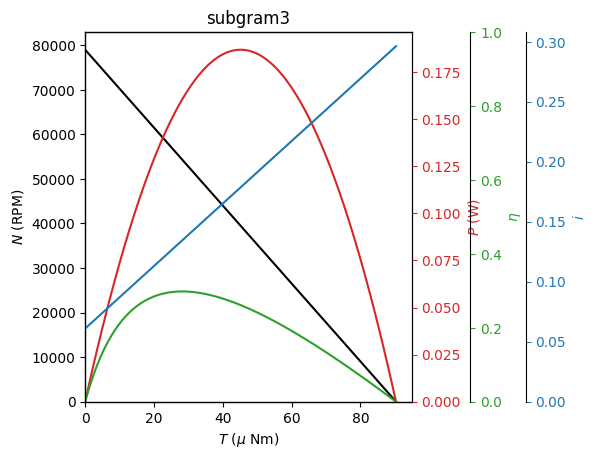

In [10]:
motor_curves_vs_T(get_row(motors, 'subgram3')[0])

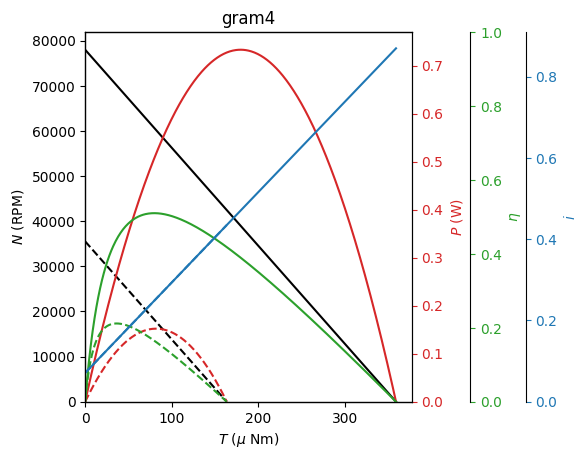

In [11]:
motor_curves_vs_T(get_row(motors, 'gram4')[0], v2=2)

In [12]:
def motor_curves_vs_n(motor, v2=None):
    "plot torque-speed curve against rpm (like qprop notes)"
    N = np.linspace(0, motor.no, 500) # RPM
    Omega = N * rpm2rads # rad/s
    i = np.linspace(motor.v/motor.R, motor.io, 500)
    #i = (motor.K * Omega - motor.v)/motor.R
    T = motor.K * (i - motor.io)
    T_uNm = T * 1e6

    P = T * Omega
    eta = P / (i * motor.v)

    if v2 is not None:
        # show 2nd voltage
        N2 = N * v2/motor.v # assume no-load rpm increases linearly with voltage, not a good assumption if io is large
        Omega2 = N2 * 2 * np.pi / 60 # rad/s
        i2 = np.linspace(v2/motor.R, motor.io, 500)
        #i = (motor.K * Omega - motor.v)/motor.R
        T2 = motor.K * (i2 - motor.io)
        T2_uNm = T2 * 1e6

        P2 = T2 * Omega2
        eta2 = P2 / (i2 * v2)

    fig, ax = plt.subplots()
    fig.subplots_adjust(right=0.65)
    twin1 = ax.twinx()
    twin2 = ax.twinx()
    twin2.spines.right.set_position(("axes", 1.18))
    twin3 = ax.twinx()
    twin3.spines.right.set_position(("axes", 1.35))

    p1, = ax.plot(N, T_uNm, "k", label=r"$T$")
    p2, = twin1.plot(N, P, "C3", label="$P$")
    p3, = twin2.plot(N, eta, "C2", label=r"$\eta$")
    p4, = twin3.plot(N, i, "C0", label=r"$i$")

    if v2 is not None:
        p1, = ax.plot(N2, T2_uNm, "k", ls="--", label=r"$T$")
        p2, = twin1.plot(N2, P2, "C3", ls="--", label="$P$")
        p3, = twin2.plot(N2, eta2, "C2", ls="--", label=r"$\eta$")
        p4, = twin3.plot(N2, i2, "C0", ls="--", label=r"$i$")

    ax.set(ylim=(0, None),
           xlabel=r"$N$ (RPM)", ylabel=r"$T$ ($\mu$ Nm)")
    twin1.set(ylim=(0, None), ylabel="$P$ (W)")
    twin2.set(ylim=(0,1), ylabel=r"$\eta$")
    twin3.set(ylim=(0,None), ylabel=r"$i$")

    ax.yaxis.label.set_color(p1.get_color())
    twin1.yaxis.label.set_color(p2.get_color())
    twin2.yaxis.label.set_color(p3.get_color())
    twin3.yaxis.label.set_color(p4.get_color())

    ax.tick_params(axis='y', colors=p1.get_color())
    twin1.tick_params(axis='y', colors=p2.get_color())
    twin2.tick_params(axis='y', colors=p3.get_color())
    twin3.tick_params(axis='y', colors=p4.get_color())
    plt.title(motor.motor)
    print(f'{max(P)=}, {max(eta)=}')

In [13]:
# propeller efficiency of coin-copter.
# what is motor efficiency? what is propeller efficiency ?
# define prop FOM: T^3/2/sqrt(2rho A)/(Q*Omega) -
eta_motor = 0.27 # Pshaft/(i*v) motor conversion efficiency, from plot above from mdm4c motor at 4V.
Pshaft = eta_motor * 4 * 0.492
print(f"{Pshaft=} W")
T = 3.2 * 9.8 / 1000 # N, thrust
rhoair = 1.2 # kg/m3
A = np.pi * (0.032/2)**2
etaprop = T**(3/2)/np.sqrt(2 * rhoair * A) / Pshaft
print(f"{etaprop=}") # helicopters get around 30%

Pshaft=0.53136 W
etaprop=np.float64(0.2378891764903505)


# estimate flight time as a function of battery size, given some specs

In [14]:
# Thermal Limits - Loss Approximations for High Power Drive
motors['A'] = 2 * np.pi * (motors.dia*1e-3/2)**2 + motors.dia*1e-3 * np.pi * motors.l*1e-3
A_fh6 = 2 * np.pi * (6e-3/2)**2 + 6e-3 * np.pi * 15e-3 # housing surface area for faulhaber 6 brushed
Rth1_fh6 = 34 #K/W, thermal resistance from coil to housing, 6mm faulhaber brushed motor
motors['Rth1'] = Rth1_fh6 * A_fh6 / motors.A  # scale by relative surface area
h = 75 # chatgpt: for 3m/s flow over a 8mm long motor (better would be 12 mm)
motors['Rth2'] = 1/(h * motors.A) # thermal resistance between the outter motor container and air ~25C
motors['Rth'] = motors.Rth1 + motors.Rth2
DeltaT = 65 # assumes max coil temp 85C - upper temp for faulhaber.
alphatherm = 0.004 # increase in resistivity for copper per degrees C
motors['Q'] = DeltaT / motors.Rth # W, thermal heat transfer from coils (technically should be q_dot = delta_T/R)
motors['R_hot'] = motors.R * (1 + alphatherm * DeltaT)  # coils hot so higher resistance, by about 1.25x
motors['i_max'] = np.sqrt(motors.Q / motors.R_hot)


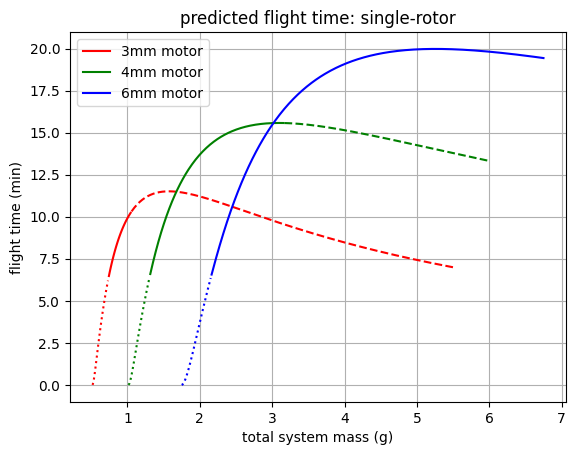

In [15]:
def rotor_flight_time_curve(motor, r_r=0.0165, m_p=450e-6):
    "return an anticipated flight time curve as a function of battery size, given rotor diameter r_r, payload m_p"
    # prop diameter, thrust, and figure of merit (FM) dictate RPM
    FM = 0.3 # figure of merit (calculated 0.25). releative aero efficiency vs bernouilli optimum lift-to-power ratio
    S_b = 500e3 #J/kg battery energy density
    eta_elec = 0.9 # electrical system efficiency (motor control)
    g = 9.81
    rho_air = 1.2
    C_T = 0.009 # rotor coefficient of thrust, assumes ~10deg AoA and 2 blades. from f_t = C_T rho_air A_r (r_r Omega)^2
    A_r = np.pi * r_r ** 2 # rotor area

    m_b = np.linspace(1e-6, 5e-3, 400) # kg, battery mass
    m = m_b + m_p + motor.m*1e-6 # vehicle mass
    f_t = m * g # N, thrust force
    Omega = 1/r_r * np.sqrt(f_t/(rho_air*C_T*A_r)) # get omega knowing thrust and prop diameter
    Pm = 1 / FM * (f_t**1.5 / np.sqrt(2 * rho_air * A_r)) # W, mechnical power
    Tf = motor.Tc + motor.b * Omega # friction torque
    Pf = Tf * Omega # friction power
    Tm = Tf + Pm / Omega # magnetic motor torque
    i = 1/motor.K * Tm
    v = i * motor.R_hot + motor.K * Omega # V, driving voltage
    # TODO: improve the following very rough estimate of battery resistance scaling
    CRb = 0.0012 # Ohms-kg. how much battery resistance Rb per unit battery mass. From Rb * mb = CRb for 20 mAh battery
    Pd = i ** 2 * motor.R_hot # electrically dissipated power
    Pd_batt = i ** 2 * CRb / m_b # W, power dissipation in battery
    Pe = 1/eta_elec * (Pd + Pf + Pm) + Pd_batt # W, total electrical power
    tf = S_b * m_b / Pe # s, flight time
    #print(f'{m=}, {Omega=}, {Pm=}, {Pd=}, {Tf=}, {T=}, {Pf=}, {i=}, {motor.i_max=}, {Pe=}, {tf=}, ')
    #print(f'motor eta = {Pm / Pe}')
    mask_therm = i < motor.i_max # binary mask of when motor is within thermal limits
    mask_batt = Pe < 1300 * m_b  # binary mask of when battery is below max power density
    return m, mask_therm, mask_batt, tf, Omega, v, i

mcp = 150e-6 # kg, mass sensor payload
mup_rotor = 0.3 # "mu_p": mass fraction for tail rotor and power electronics

plt.figure()
ax = plt.gca()

r_array = (0.014, .015, .020) # m, approximately optimal rotor size (pretty wide bowl here, so exact value not as important)
for idx, motorname in enumerate(('subgram3', 'gram4', 'multigram6')):
    motor = get_row(motors, motorname)[0]
    m_p = mup_rotor * motor.m * 1e-6 + mcp # kg, heli with tail rotor
    r = r_array[idx]
    color = 'rgbc'[idx]
    names = ('3mm motor', '4mm motor', '6mm motor')
    m, mask_therm, mask_batt, tf, Omega, v, i = rotor_flight_time_curve(motor, r_r=r, m_p=m_p)
    ax.plot(m[mask_therm & mask_batt]*1000, 1/60*tf[mask_therm & mask_batt], color=color, label=names[idx])
    ax.plot(m[~mask_therm]*1000, 1/60*tf[~mask_therm], color=color, linestyle='--')
    ax.plot(m[~mask_batt]*1000, 1/60*tf[~mask_batt], color=color, linestyle=':')
    #print(min(m[mask_therm & mask_batt]*1000))

ax.set_xlabel('total system mass (g)')
ax.set_ylabel('flight time (min)')
ax.set_title('predicted flight time: single-rotor')
plt.grid()
plt.legend()